<a href="https://www.kaggle.com/code/kaushikfreddyregalla/05-model-evaluation?scriptVersionId=325255714" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 05 — Model Evaluation
Confusion Matrix | Classification Report | ROC Curves | Model Comparison

Hand Gesture Recognition | Kaushik Reddy Ragalla

In [1]:
import os, sys, io, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
_stderr = sys.stderr; sys.stderr = io.StringIO()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, optimizers
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize
sys.stderr = _stderr

os.makedirs('figures', exist_ok=True)
CLASS_NAMES = ['01_palm','02_l','03_fist','04_fist_moved','05_thumb',
               '06_index','07_ok','08_palm_moved','09_c','10_down']
NUM_CLASSES = 10
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

# ── Find .npy files ──────────────────────────────────────────────────────────
NPY_DIR = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'X_test.npy' in files:
        NPY_DIR = root; break
if NPY_DIR is None and os.path.exists('/kaggle/working/X_test.npy'):
    NPY_DIR = '/kaggle/working'
assert NPY_DIR, 'X_test.npy not found!'
print(f'NPY from: {NPY_DIR}')
X_test     = np.load(f'{NPY_DIR}/X_test.npy')
y_test     = np.load(f'{NPY_DIR}/y_test.npy')
X_test_rgb = np.repeat(X_test, 3, axis=-1)
print(f'Test set: {X_test.shape[0]} images')

# ── Find model files anywhere under /kaggle ──────────────────────────────────
def find_model(name):
    for root, dirs, files in os.walk('/kaggle'):
        if name in files:
            return os.path.join(root, name)
    return None

cnn_path = find_model('best_custom_cnn.keras')
mob_path = find_model('best_mobilenet.keras')
vgg_path = find_model('best_vgg16.keras')
print(f'CNN     : {cnn_path}')
print(f'MobileNet: {mob_path}')
print(f'VGG16   : {vgg_path}')

# ── If CNN model missing, retrain quickly ────────────────────────────────────
if cnn_path is None:
    print('\nCNN model not found — retraining (takes ~15 min with GPU)...')
    from tensorflow.keras import layers, models, callbacks, regularizers
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    from tensorflow.keras.utils import to_categorical
    X_train = np.load(f'{NPY_DIR}/X_train.npy')
    y_train = np.load(f'{NPY_DIR}/y_train.npy')
    X_val   = np.load(f'{NPY_DIR}/X_val.npy')
    y_val   = np.load(f'{NPY_DIR}/y_val.npy')
    inp = layers.Input(shape=(128,128,1))
    x = inp
    for f in [32,64,128,256]:
        x = layers.Conv2D(f,(3,3),padding='same',kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Conv2D(f,(3,3),padding='same',kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        if f < 256:
            x = layers.MaxPooling2D((2,2))(x)
            x = layers.Dropout(0.25)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256,activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(NUM_CLASSES,activation='softmax')(x)
    cnn_model = models.Model(inp, out)
    cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    dg = ImageDataGenerator(rotation_range=15,width_shift_range=0.1,
                            height_shift_range=0.1,zoom_range=0.1,
                            horizontal_flip=True,fill_mode='nearest')
    cnn_model.fit(dg.flow(X_train,y_train,batch_size=32,seed=42),
                  steps_per_epoch=len(X_train)//32, epochs=15,
                  validation_data=(X_val,y_val), verbose=1)
    cnn_model.save('/kaggle/working/best_custom_cnn.keras')
    cnn_path = '/kaggle/working/best_custom_cnn.keras'
    print('CNN retrained and saved.')
else:
    cnn_model = tf.keras.models.load_model(cnn_path)

assert mob_path, 'best_mobilenet.keras not found! Attach notebook 04 output.'
assert vgg_path, 'best_vgg16.keras not found! Attach notebook 04 output.'
mobilenet_model = tf.keras.models.load_model(mob_path)
vgg_model       = tf.keras.models.load_model(vgg_path)
print('All models loaded.')


E0000 00:00:1780865954.313896      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780865954.366920      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780865954.803220      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780865954.803253      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780865954.803256      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780865954.803259      23 computation_placer.cc:177] computation placer already registered. Please check linka

NPY from: /kaggle/input/notebooks/kaushikfreddyregalla/02-preprocessing-data-augmentation
Test set: 3000 images
CNN     : None
MobileNet: /kaggle/input/notebooks/kaushikfreddyregalla/04-transfer-learning-mobilenetv2-vgg16/best_mobilenet.keras
VGG16   : /kaggle/input/notebooks/kaushikfreddyregalla/04-transfer-learning-mobilenetv2-vgg16/best_vgg16.keras

CNN model not found — retraining (takes ~15 min with GPU)...


I0000 00:00:1780866073.595484      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780866073.601241      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/15


I0000 00:00:1780866080.333969      69 service.cc:152] XLA service 0x7d1f800216b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780866080.334021      69 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780866080.334028      69 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780866081.362554      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/437 ━━━━━━━━━━━━━━━━━━━━ 34s 79ms/step - accuracy: 0.1328 - loss: 2.4700   

I0000 00:00:1780866094.563651      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


437/437 ━━━━━━━━━━━━━━━━━━━━ 58s 89ms/step - accuracy: 0.7680 - loss: 0.7804 - val_accuracy: 0.1037 - val_loss: 6.0567
Epoch 2/15
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9688 - loss: 0.2375 - val_accuracy: 0.1133 - val_loss: 5.4253
Epoch 3/15
437/437 ━━━━━━━━━━━━━━━━━━━━ 25s 57ms/step - accuracy: 0.9646 - loss: 0.2157 - val_accuracy: 0.9947 - val_loss: 0.1170
Epoch 4/15
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.1242 - val_accuracy: 0.9940 - val_loss: 0.1199
Epoch 5/15
437/437 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.9763 - loss: 0.1769 - val_accuracy: 0.7880 - val_loss: 0.9496
Epoch 6/15
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 0.1155 - val_accuracy: 0.7517 - val_loss: 1.4043
Epoch 7/15
437/437 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.9800 - loss: 0.1564 - val_accuracy: 0.8513 - val_loss: 0.6781
Epoch 8/15
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 0.1015 - val_accuracy: 0.830

In [2]:
# ── Get predictions ──────────────────────────────────────────────────────────
def get_preds(model, X):
    y_prob = model.predict(X, verbose=0)
    return np.argmax(y_prob, axis=1), y_prob

y_true = np.argmax(y_test, axis=1)

y_pred_cnn, y_prob_cnn = get_preds(cnn_model,       X_test)
y_pred_mob, y_prob_mob = get_preds(mobilenet_model,  X_test_rgb)
y_pred_vgg, y_prob_vgg = get_preds(vgg_model,        X_test_rgb)

acc_cnn = (y_true == y_pred_cnn).mean()
acc_mob = (y_true == y_pred_mob).mean()
acc_vgg = (y_true == y_pred_vgg).mean()

print(f'Custom CNN   : {acc_cnn*100:.2f}%')
print(f'MobileNetV2  : {acc_mob*100:.2f}%')
print(f'VGG16        : {acc_vgg*100:.2f}%')

Custom CNN   : 96.73%
MobileNetV2  : 99.93%
VGG16        : 99.93%


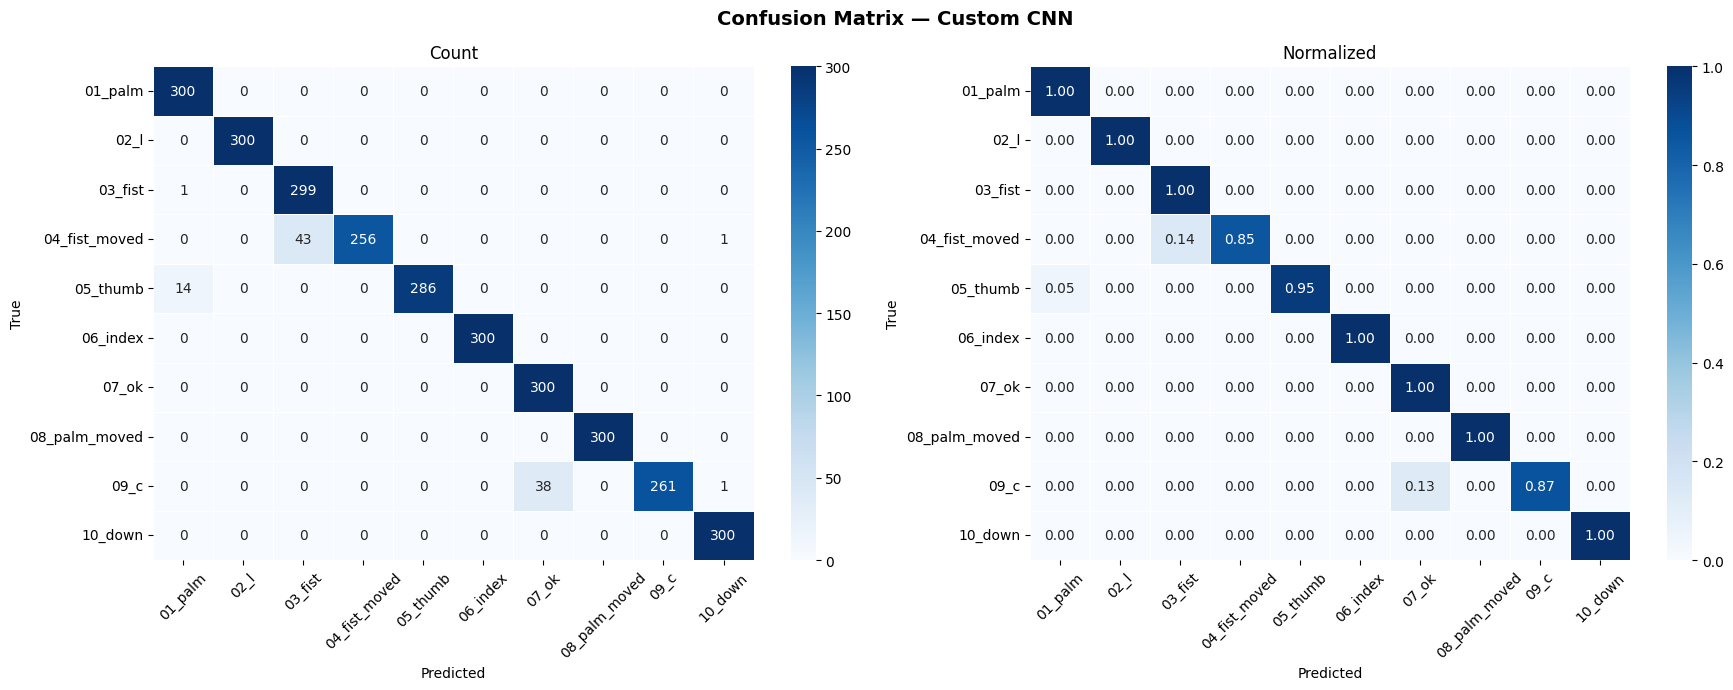

Saved: figures/confusion_matrix_cnn.png


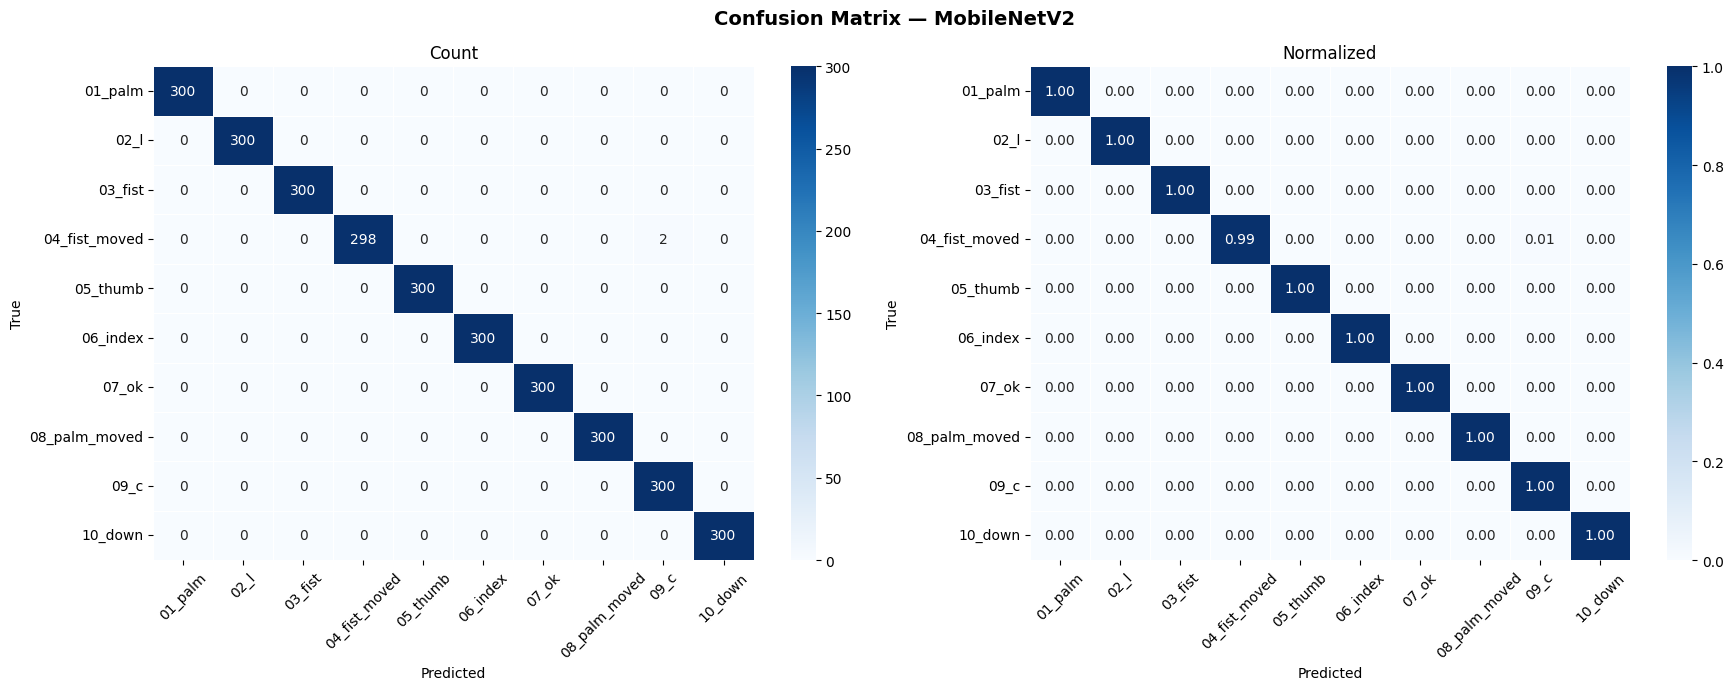

Saved: figures/confusion_matrix_mobilenet.png


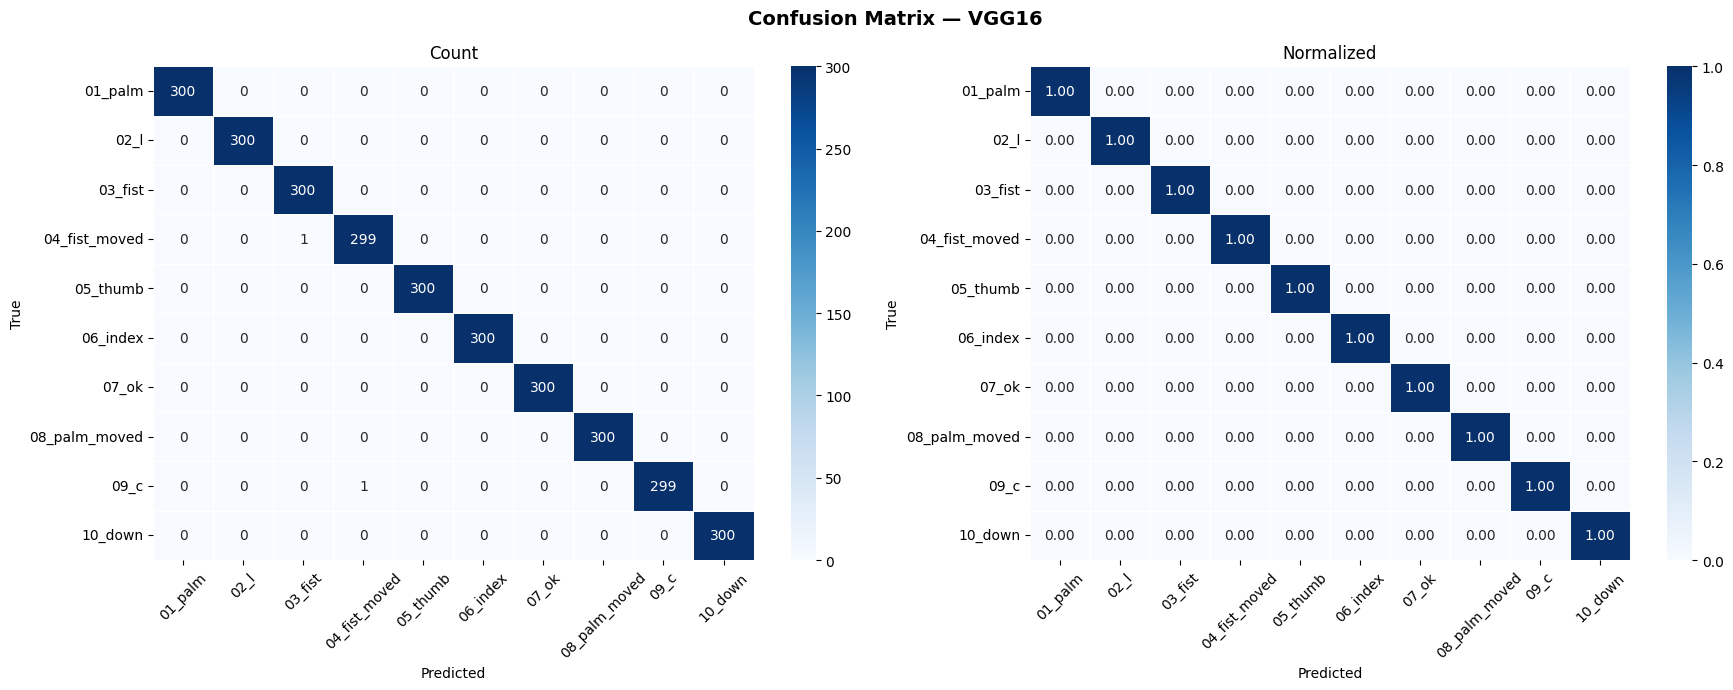

Saved: figures/confusion_matrix_vgg16.png


In [3]:
# ── Confusion Matrices ───────────────────────────────────────────────────────
def plot_cm(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for ax, data, fmt, t in zip(axes, [cm, cm_norm], ['d', '.2f'], ['Count', 'Normalized']):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, linewidths=0.5)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(t)
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f'Saved: {save_path}')

plot_cm(y_true, y_pred_cnn, 'Confusion Matrix — Custom CNN',  'figures/confusion_matrix_cnn.png')
plot_cm(y_true, y_pred_mob, 'Confusion Matrix — MobileNetV2', 'figures/confusion_matrix_mobilenet.png')
plot_cm(y_true, y_pred_vgg, 'Confusion Matrix — VGG16',       'figures/confusion_matrix_vgg16.png')

In [4]:
# ── Classification Reports ───────────────────────────────────────────────────
for name, y_pred in [('Custom CNN', y_pred_cnn), ('MobileNetV2', y_pred_mob), ('VGG16', y_pred_vgg)]:
    print(f'\n{"="*55}\nCLASSIFICATION REPORT — {name}\n{"="*55}')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


CLASSIFICATION REPORT — Custom CNN
               precision    recall  f1-score   support

      01_palm       0.95      1.00      0.98       300
         02_l       1.00      1.00      1.00       300
      03_fist       0.87      1.00      0.93       300
04_fist_moved       1.00      0.85      0.92       300
     05_thumb       1.00      0.95      0.98       300
     06_index       1.00      1.00      1.00       300
        07_ok       0.89      1.00      0.94       300
08_palm_moved       1.00      1.00      1.00       300
         09_c       1.00      0.87      0.93       300
      10_down       0.99      1.00      1.00       300

     accuracy                           0.97      3000
    macro avg       0.97      0.97      0.97      3000
 weighted avg       0.97      0.97      0.97      3000


CLASSIFICATION REPORT — MobileNetV2
               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00       300
         02_l       1.00      1.00      1.0

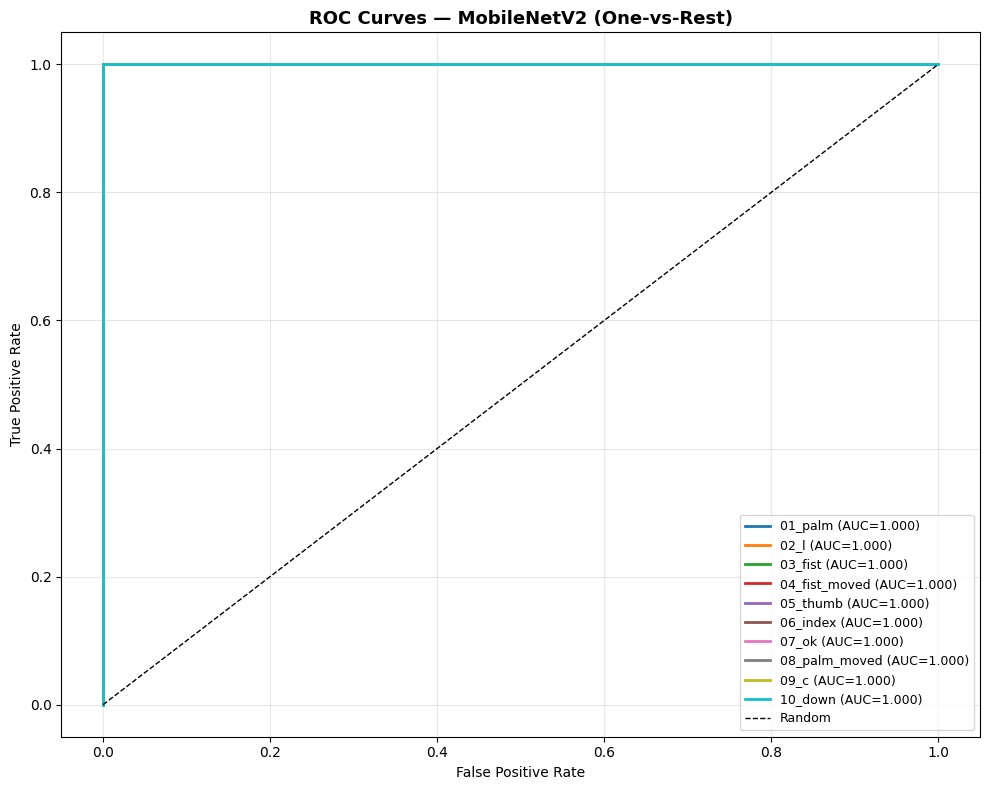

In [5]:
# ── ROC Curves — MobileNetV2 (one-vs-rest) ───────────────────────────────────
y_test_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(10, 8))
for i, (cls, color) in enumerate(zip(CLASS_NAMES, plt.cm.tab10.colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_mob[:, i])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC={auc(fpr,tpr):.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — MobileNetV2 (One-vs-Rest)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/roc_curves.png', dpi=150)
plt.show()

In [6]:
# ── Model Comparison Table ───────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model'           : ['Custom CNN', 'MobileNetV2', 'VGG16'],
    'Test Accuracy'   : [f'{acc_cnn*100:.2f}%', f'{acc_mob*100:.2f}%', f'{acc_vgg*100:.2f}%'],
    'Parameters'      : [f'{cnn_model.count_params():,}',
                         f'{mobilenet_model.count_params():,}',
                         f'{vgg_model.count_params():,}'],
    'Input Size'      : ['128x128x1', '128x128x3', '128x128x3'],
    'Pretrained'      : ['No', 'ImageNet', 'ImageNet']
})
print(comparison.to_string(index=False))
comparison.to_csv('figures/model_comparison.csv', index=False)
print('Saved: figures/model_comparison.csv')

      Model Test Accuracy Parameters Input Size Pretrained
 Custom CNN        96.73%  1,243,882  128x128x1         No
MobileNetV2        99.93%  2,588,490  128x128x3   ImageNet
      VGG16        99.93% 14,848,586  128x128x3   ImageNet
Saved: figures/model_comparison.csv
